In [ ]:
# prompt: 讀取 housing.csv ,分隔符號為空白，并請顯示前五筆資料,第一筆是資料，不是欄位名稱，欄位名稱自訂(exZN,IND等有關影響房價的指標)，

import pandas as pd

# 讀取 CSV 檔案，指定分隔符號為空白，並跳過第一列 (假設第一列不是欄位名稱)
try:
    df = pd.read_csv('housing.csv', delim_whitespace=True, header=None, skiprows=1)
except FileNotFoundError:
    print("Error: 'housing.csv' not found. Please upload the file to your current directory.")
    exit()


# 自訂欄位名稱
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df.columns = column_names

# 顯示前五筆資料
df.head()


C:\Users\User\AppData\Local\Temp\ipykernel_21288\2340538672.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('housing.csv', delim_whitespace=True, header=None, skiprows=1)


Error: 'housing.csv' not found. Please upload the file to your current directory.


NameError: name 'df' is not defined

: 

In [28]:
# prompt: 請移除df資料中的空白值，僅需要顯示該動作的程式碼，再顯示前五筆資料以進行檢查

df = df.dropna()
df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [1]:
# prompt: 請針對df資料進行simple linear regrassion,目標變數為MEDV，其他則爲特徵變數，
# （先不用畫圖）

import statsmodels.api as sm

# Define the target variable (MEDV) and predictor variables (all others)
y = df['MEDV']
X = df.drop('MEDV', axis=1)

# Add a constant to the predictor variables (intercept term)
X = sm.add_constant(X)

# Fit the simple linear regression model
model = sm.OLS(y, X).fit()

# Print the model summary
print(model.summary())


ModuleNotFoundError: No module named 'statsmodels'

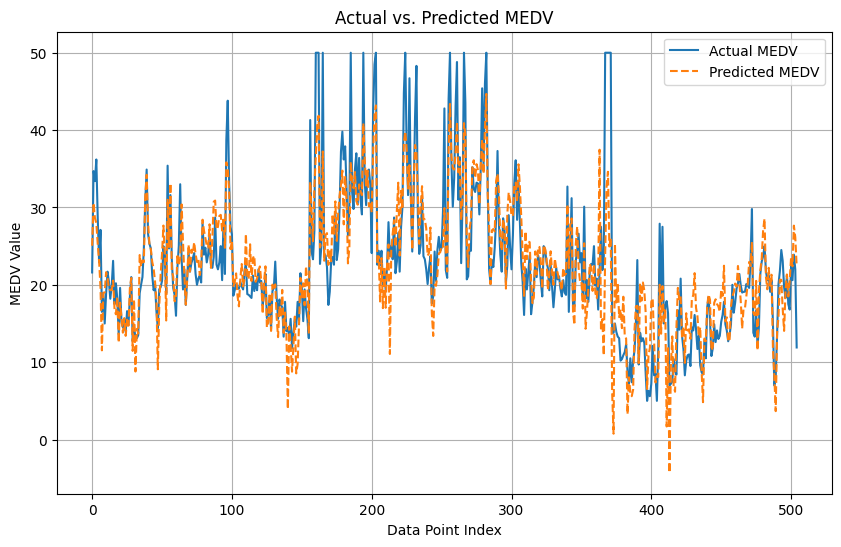

In [46]:
# prompt: 請針對MEDV，去繪製曲綫圖，y值為實際值 與 預測值（有兩條曲綫），x則爲每一筆資料

import matplotlib.pyplot as plt

# ... (your existing code) ...

# Make predictions
predictions = model.predict(X)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(y.values, label='Actual MEDV',  linestyle='-')
plt.plot(predictions.values, label='Predicted MEDV', linestyle='--')
plt.xlabel('Data Point Index')
plt.ylabel('MEDV Value')
plt.title('Actual vs. Predicted MEDV')
plt.legend()
plt.grid(True)
plt.show()
